# Compare pump samples by matching region

Select one `pump_no` and `fault`. Calculate `FEATURES` separately for every
sample, state, sensor, channel, and interval between adjacent changepoints.
Region numbers begin at **1**. Three boundaries define two regions; five define four.
Each sample/sensor uses its own boundary indices in the original CSV row order.
Data before the first and after the last boundary is excluded.

The comparison assumes region numbers describe the same operating stage across runs.
Different region counts raise an error; equal counts cannot prove stage alignment.
Complete regions may have different durations; `n_rows` records their lengths.

This is a raw-region diagnostic: no scaling, centering, absolute-value transform,
quantile trimming, or fixed training window is applied. Measurement units must match
across samples. CSV row filtering before slicing would invalidate these indices.
This notebook targets the combined pump schema shown in the original notebook.
Legacy measurement columns are detected automatically; other schemas require
an explicit `column_map` and compatible row-index changepoints.

In [1]:
import re
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

In [2]:
meta = pd.read_csv("pump_meta_combined_all_faults_mapped.csv", dtype={"fault_id": str})
meta.head()

,fault_id,pump_id,sample_id,state,AC1,GYR,CTB,CTR,CV1,VRY,PRS,SMG,WTF
0,00000000000_,1,1,air,D:\VGuard Ahemedebad Data\Primary_20230727-31\...,D:\VGuard Ahemedebad Data\Primary_20230727-31\...,D:\VGuard Ahemedebad Data\Primary_20230727-31\...,D:\VGuard Ahemedebad Data\Primary_20230727-31\...,D:\VGuard Ahemedebad Data\Primary_20230727-31\...,D:\VGuard Ahemedebad Data\Primary_20230727-31\...,NaN,D:\VGuard Ahemedebad Data\Primary_20230727-31\...,NaN
1,00000000000_,1,1,water,D:\VGuard Ahemedebad Data\Primary_20230727-31\...,D:\VGuard Ahemedebad Data\Primary_20230727-31\...,D:\VGuard Ahemedebad Data\Primary_20230727-31\...,D:\VGuard Ahemedebad Data\Primary_20230727-31\...,D:\VGuard Ahemedebad Data\Primary_20230727-31\...,D:\VGuard Ahemedebad Data\Primary_20230727-31\...,D:\VGuard Ahemedebad Data\Primary_20230727-31\...,D:\VGuard Ahemedebad Data\Primary_20230727-31\...,D:\VGuard Ahemedebad Data\Primary_20230727-31\...
2,00000000000_,1,4,air,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,NaN,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,NaN
3,00000000000_,1,4,water,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,D:\VGuard Ahemedebad Data\Primary_20230726\No ...
4,00000000000_,2,1,air,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,NaN,D:\VGuard Ahemedebad Data\Primary_20230726\No ...,NaN


In [3]:
ts = pd.read_csv("pump_signalwise_timestamp_combined.csv", dtype={"id": str, "indices": str})
ts.head()

,id,indices,key,state
0,AC1_00000000000_@1@1@air,35707#221439#465122,AC1,air
1,GYR_00000000000_@1@1@air,38744#240273#504682,GYR,air
2,CTB_00000000000_@1@1@air,88966#551730#1158884,CTB,air
3,CTR_00000000000_@1@1@air,88123#546504#1147907,CTR,air
4,CV1_00000000000_@1@1@air,49146#304781#640179,CV1,air


In [4]:
FEATURES = ['mean', 'std', 'skew', 'kurt', 'rms', 'mad']

Feature definitions:

| Feature | Calculation |
|---|---|
| mean | Arithmetic mean of the region values |
| std | Population standard deviation (`ddof=0`) |
| skew | Bias-corrected skewness |
| kurt | Bias-corrected excess kurtosis (normal-distribution reference = 0) |
| rms | Square root of the mean squared value |
| mad | Median absolute deviation from the median; no scale factor |

Nonfinite/nonnumeric values are removed **after** region slicing and counted in
`n_invalid`. At least four finite values are required. Skew/kurtosis of constant
or numerically near-constant regions are undefined (`NaN`), rather than invented zeros.
Missing sensor paths are listed in `skipped`; missing files/changepoints and invalid
boundaries raise errors so incomplete results are not silently returned.

In [5]:
def compare_samples(pump_no, fault, state=None, signals=None, *,
                    meta_df=None, ts_df=None, column_map=None):
    """Compare samples of one pump/fault using each sample's own regions.

    Uses the global meta, ts and FEATURES unless DataFrames are supplied.
    Region 1 = rows [cp[0]:cp[1]], Region 2 = [cp[1]:cp[2]], etc.
    Indices refer to the ORIGINAL CSV row order; no rows are removed first.
    column_map optionally maps a signal to its CSV measurement columns.
    Returns: features, comparison, pairwise, skipped (all DataFrames).
    """
    m = (meta if meta_df is None else meta_df).copy()
    t = (ts if ts_df is None else ts_df).copy()
    requested = list(FEATURES)
    supported = {'mean', 'std', 'skew', 'kurt', 'rms', 'mad'}
    if not requested or set(requested) - supported:
        raise ValueError(f'FEATURES must contain names from {sorted(supported)}')
    required = {'fault_id', 'pump_id', 'sample_id', 'state'}
    if not required.issubset(m.columns) or not {'id', 'indices'}.issubset(t.columns):
        raise ValueError('Use the combined pump metadata and signalwise timestamps CSVs.')

    def id_text(value):
        value = str(value).strip()
        return str(int(value)) if re.fullmatch(r'\d+(?:\.0+)?', value) else value

    for col in ['pump_id', 'sample_id']:
        if m[col].isna().any():
            raise ValueError(f'Missing {col} in metadata.')
        m[col] = m[col].map(id_text)
    m['fault_id'] = m['fault_id'].astype(str).str.strip()
    m['state'] = m['state'].astype(str).str.strip().str.lower()
    fault = str(fault).strip()  # Pass the full ID, including leading zeros and '_'.
    selected = m[(m['pump_id'] == id_text(pump_no)) & (m['fault_id'] == fault)]
    if state is not None:
        selected = selected[selected['state'] == str(state).strip().lower()]
    if selected.empty:
        raise ValueError(f'No samples found for pump={pump_no}, fault={fault}, state={state}.')
    if selected.duplicated(['sample_id', 'state']).any():
        raise ValueError('Duplicate sample/state rows. Filter the source/run first; do not mix pumps.')
    if selected['sample_id'].nunique() < 2:
        raise ValueError('At least two different samples are required for comparison.')

    known_signals = ['AC1', 'AC2', 'GYR', 'CTB', 'CTR', 'CV1', 'VRY', 'PRS', 'SMG', 'WTF']
    signals = ([s for s in known_signals if s in selected.columns]
               if signals is None else ([signals] if isinstance(signals, str) else list(signals)))
    if not signals or any(s not in selected.columns for s in signals):
        raise ValueError('signals must name sensor path columns in metadata.')
    column_map = {} if column_map is None else column_map
    t['id'] = t['id'].astype(str).str.strip()
    wanted = {f'{sig}_{fault}@{row.pump_id}@{row.sample_id}@{row.state}'
              for row in selected.itertuples() for sig in signals}
    t = t[t['id'].isin(wanted)]
    if t['id'].duplicated().any():
        raise ValueError('Duplicate changepoint IDs in the timestamp file.')
    lookup = t.set_index('id')['indices'].to_dict()
    records, skipped = [], []
    region_counts = {}

    for _, row in selected.iterrows():
        for sig in signals:
            context = dict(fault_id=fault, pump_id=row['pump_id'],
                           sample_id=row['sample_id'], state=row['state'], signal=sig)
            path = row[sig]
            if pd.isna(path) or not str(path).strip():
                skipped.append({**context, 'reason': 'No sensor path in metadata'})
                continue  # For example, PRS/WTF are absent in Air.
            cp_id = f"{sig}_{fault}@{row['pump_id']}@{row['sample_id']}@{row['state']}"
            if cp_id not in lookup:
                raise ValueError(f'Missing changepoints: {cp_id}')
            try:
                cp = np.array([int(v.strip()) for v in str(lookup[cp_id]).split('#')], dtype=np.int64)
            except (ValueError, OverflowError) as exc:
                raise ValueError(f'Invalid integer row indices: {cp_id}') from exc
            if len(cp) < 2 or cp[0] < 0 or np.any(np.diff(cp) <= 0):
                raise ValueError(f'Changepoints must be nonnegative and strictly increasing: {cp_id}')
            count_key = (row['state'], sig)
            previous = region_counts.setdefault(count_key, len(cp) - 1)
            if previous != len(cp) - 1:
                raise ValueError(f'Different region counts for {count_key}; check region alignment.')

            path = str(path).strip()
            header = pd.read_csv(path, nrows=0).columns.tolist()
            if sig in column_map:
                columns = column_map[sig]
                columns = [columns] if isinstance(columns, str) else list(columns)
            else:
                # Legacy measurement headers: column_0, column_1, ... (or 0, 1, ...).
                # Never treat timestamps or CSV index columns as measurements.
                columns = [c for c in header if re.fullmatch(r'(?:column_|col_)?\d+', c)]
            if not columns or any(c not in header for c in columns):
                raise ValueError(f'No valid measurement columns for {sig}. '
                                 f'Set column_map explicitly. Available: {header}')
            if len(columns) != len(set(columns)):
                raise ValueError(f'Duplicate columns in column_map for {sig}.')
            # Only one sensor file in memory; ignore data after the final boundary.
            data = pd.read_csv(path, usecols=columns, nrows=int(cp[-1]))
            if cp[-1] > len(data):
                raise ValueError(f'Changepoint {cp[-1]} exceeds {len(data)} rows: {path}')

            for region, (start, end) in enumerate(zip(cp[:-1], cp[1:]), start=1):
                for channel in columns:
                    x = pd.to_numeric(data[channel].iloc[start:end], errors='coerce').to_numpy(dtype=float)
                    n_rows = len(x)
                    x = x[np.isfinite(x)]  # Only after slicing: retain original region alignment.
                    if len(x) < 4:
                        raise ValueError(f'Fewer than 4 finite values: {cp_id}, region={region}, {channel}')
                    median = np.median(x)
                    near_constant = np.ptp(x) <= 1e-12 * max(1.0, float(np.max(np.abs(x))))
                    values = {
                        'mean': float(np.mean(x)),
                        'std': float(np.std(x, ddof=0)),
                        'skew': np.nan if near_constant else float(skew(x, bias=False)),
                        'kurt': np.nan if near_constant else float(kurtosis(x, fisher=True, bias=False)),
                        'rms': float(np.sqrt(np.mean(x ** 2))),
                        'mad': float(np.median(np.abs(x - median))),
                    }
                    records.append({**context, 'channel': channel, 'region': region,
                                    'start_row': int(start), 'end_row_exclusive': int(end),
                                    'n_rows': n_rows, 'n_valid': len(x),
                                    'n_invalid': n_rows - len(x),
                                    'near_constant': near_constant,
                                    **{f: values[f] for f in requested}})
            del data

    if not records:
        raise ValueError('No sensor data found for the selected samples.')
    features = pd.DataFrame(records)
    keys = ['fault_id', 'pump_id', 'state', 'signal', 'channel', 'region']
    long = features.melt(id_vars=keys + ['sample_id'], value_vars=requested,
                         var_name='feature', value_name='value')
    sample_order = sorted(features['sample_id'].unique(),
                          key=lambda s: (0, int(s)) if s.isdigit() else (1, s))
    comparison = long.pivot(index=keys + ['feature'], columns='sample_id', values='value')
    comparison = comparison.reindex(columns=sample_order).sort_index()
    comparison.columns = [f'sample_{s}' for s in comparison.columns]

    # Compute differences only between the same state/signal/channel/region/feature.
    pairs = []
    for key, group in long.groupby(keys + ['feature'], sort=False):
        by_sample = group.set_index('sample_id')['value']
        present = [s for s in sample_order if s in by_sample.index]
        for a, b in combinations(present, 2):
            va, vb = float(by_sample[a]), float(by_sample[b])
            valid = np.isfinite(va) and np.isfinite(vb)
            difference = vb - va if valid else np.nan
            denominator = abs(va) + abs(vb)
            pct = (200.0 * abs(difference) / denominator if denominator else 0.0) if valid else np.nan
            pairs.append({**dict(zip(keys + ['feature'], key)),
                          'sample_a': a, 'sample_b': b, 'value_a': va, 'value_b': vb,
                          'difference_b_minus_a': difference, 'absolute_difference': abs(difference),
                          'symmetric_difference_pct': pct})
    pair_columns = keys + ['feature', 'sample_a', 'sample_b', 'value_a', 'value_b',
                           'difference_b_minus_a', 'absolute_difference', 'symmetric_difference_pct']
    pairwise = pd.DataFrame(pairs, columns=pair_columns)
    if pairwise.empty:
        raise ValueError('No matching state/signal/channel/region exists across two samples.')
    return {'features': features, 'comparison': comparison,
            'pairwise': pairwise,
            'skipped': pd.DataFrame(skipped, columns=list(context) + ['reason'])}

In [6]:
def plot(result, signal, channel, state='water', region=1):
    """One subplot per feature for one matching region/channel across samples."""
    data = result['features']
    data = data[(data['signal'] == signal) & (data['channel'] == channel)
                & (data['state'] == state.lower()) & (data['region'] == region)]
    if data.empty:
        raise ValueError('No feature rows match the requested plot.')
    data = data.copy()
    order = sorted(data['sample_id'].unique(),
                   key=lambda s: (0, int(s)) if s.isdigit() else (1, s))
    data = data.set_index('sample_id').loc[order]
    chosen = [f for f in FEATURES if f in data.columns]
    fig, axes = plt.subplots(int(np.ceil(len(chosen) / 3)), 3,
                             figsize=(13, 3.5 * int(np.ceil(len(chosen) / 3))), squeeze=False)
    for ax, feature in zip(axes.flat, chosen):
        values = data[feature].to_numpy()
        ax.bar(np.arange(len(data)), values, color='#2878A0')
        ax.set_xticks(np.arange(len(data)))
        ax.set_xticklabels([f'Sample {s}' for s in data.index], rotation=30)
        ax.set_title(feature)
        ax.grid(axis='y', alpha=0.2)
        for i, value in enumerate(values):
            if not np.isfinite(value):
                ax.text(i, 0.5, 'undefined', rotation=90, ha='center', transform=ax.get_xaxis_transform())
    for ax in list(axes.flat)[len(chosen):]:
        ax.set_visible(False)
    first = data.iloc[0]
    fig.suptitle(f"Pump {first['pump_id']} | {first['fault_id']} | {state} | "
                 f'{signal}/{channel} | Region {region}')
    fig.tight_layout()
    return fig

In [7]:
def plot_sample_regions(pump_no, fault, signal, channel, state='water',
                        sample_ids=None, *, meta_df=None, ts_df=None,
                        figsize=None, sharey=True, annotation_fontsize=8):
    """Full raw trace per sample, changepoint lines, and per-region features.

    Returns (fig, axes, result). Uses original CSV row numbers on the x-axis.
    All CSV rows are plotted, including before/after the defined regions.
    Feature values are computed on each complete [start, end) region only.
    No downsampling, smoothing, scaling or row deletion is used for plotting.
    """
    def id_text(value):
        value = str(value).strip()
        return str(int(value)) if re.fullmatch(r'\d+(?:\.0+)?', value) else value

    m = (meta if meta_df is None else meta_df).copy()
    state = str(state).strip().lower()
    if sample_ids is not None:
        if isinstance(sample_ids, (str, int, float, np.integer)):
            sample_ids = [sample_ids]
        wanted = {id_text(s) for s in sample_ids}
        m = m[m['sample_id'].map(id_text).isin(wanted)]
        matching = m[(m['pump_id'].map(id_text) == id_text(pump_no))
                     & (m['fault_id'].astype(str).str.strip() == str(fault).strip())
                     & (m['state'].astype(str).str.strip().str.lower() == state)]
        missing = wanted - set(matching['sample_id'].map(id_text))
        if missing:
            raise ValueError(f'Requested samples not found for this pump/fault/state: {sorted(missing)}')

    # Reuse the exact same region slicing and feature definitions as the table.
    result = compare_samples(pump_no, fault, state=state, signals=[signal],
                             meta_df=m, ts_df=ts_df, column_map={signal: [channel]})
    features = result['features']
    sample_order = sorted(features['sample_id'].unique(),
                          key=lambda s: (0, int(s)) if s.isdigit() else (1, s))
    if len(sample_order) < 2:
        raise ValueError('At least two samples with this signal are required.')
    m['pump_id'] = m['pump_id'].map(id_text)
    m['sample_id'] = m['sample_id'].map(id_text)
    m['state'] = m['state'].astype(str).str.strip().str.lower()
    m['fault_id'] = m['fault_id'].astype(str).str.strip()
    m = m[(m['pump_id'] == id_text(pump_no))
          & (m['fault_id'] == str(fault).strip()) & (m['state'] == state)]
    paths = m.set_index('sample_id')[signal]
    chosen = [f for f in FEATURES if f in features.columns]
    if figsize is None:
        figsize = (18, 4.2 * len(sample_order))
    fig, axes_grid = plt.subplots(len(sample_order), 1, figsize=figsize,
                                 sharex=True, sharey=sharey, squeeze=False)
    axes = axes_grid[:, 0]
    colors = plt.get_cmap('tab10')
    max_rows = 0
    try:
        for ax, sample in zip(axes, sample_order):
            # No nrows restriction: display the ENTIRE signal, not just regions.
            frame = pd.read_csv(str(paths.loc[sample]).strip(), usecols=[channel])
            y = pd.to_numeric(frame[channel], errors='coerce').to_numpy(dtype=float)
            y[~np.isfinite(y)] = np.nan  # Gaps remain at their original positions.
            max_rows = max(max_rows, len(y))
            ax.plot(np.arange(len(y)), y, color='#244760', lw=0.55,
                    alpha=0.85, rasterized=True, zorder=2)
            regions = features[features['sample_id'] == sample].sort_values('region')
            boundaries = sorted(set(regions['start_row']) | set(regions['end_row_exclusive']))
            for boundary in boundaries:
                ax.axvline(boundary, color='#b42318', ls='--', lw=1.1, zorder=3)
            for _, row in regions.iterrows():
                start, end = int(row['start_row']), int(row['end_row_exclusive'])
                region = int(row['region'])
                ax.axvspan(start, end, color=colors((region - 1) % 10), alpha=0.08, zorder=0)
                lines = [f'Region {region}']
                for feature in chosen:
                    value = row[feature]
                    lines.append(f'{feature}: {value:.4g}' if np.isfinite(value)
                                 else f'{feature}: undefined')
                if row['n_invalid']:
                    lines.append(f"invalid: {int(row['n_invalid'])}")
                ax.text((start + end) / 2, 0.97, '\n'.join(lines),
                        transform=ax.get_xaxis_transform(), ha='center', va='top',
                        fontsize=annotation_fontsize, family='monospace', zorder=4,
                        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                                  edgecolor=colors((region - 1) % 10), alpha=0.90))
            ax.set_title(f'Sample {sample} | {len(y):,} rows', loc='left', fontsize=11)
            ax.set_ylabel(f'{signal} / {channel}\nRaw value')
            ax.grid(axis='y', alpha=0.15)
            ax.tick_params(axis='x', labelbottom=True)
            ax.ticklabel_format(axis='x', style='plain', useOffset=False)
            del frame, y
        axes[-1].set_xlim(0, max_rows)
        axes[-1].set_xlabel('Original CSV row index (zero-based)')
        fig.suptitle(f'Pump {id_text(pump_no)} | Fault {fault} | {state.upper()} | {signal}/{channel}\n'
                     'Dashed lines: changepoints | Shading: corresponding regions', fontsize=13)
        fig.tight_layout(rect=(0, 0, 1, 0.97))
    except Exception:
        plt.close(fig)
        raise
    return fig, axes, result


## Run the comparison

The metadata and timestamp CSVs must be next to this notebook, or update their paths
above. The signal paths inside metadata must exist on your computer.
The example compares all available samples for pump 1 and the healthy fault ID;
sample IDs need not be consecutive. Change `fault` to the required full fault ID.

In [8]:
result = compare_samples(pump_no=1, fault="00000000000_")

# One feature per row; one sample per column, matched within each region.
display(result['comparison'])


sample_1  \
fault_id     pump_id state signal channel  region feature                
00000000000_ 1       air   AC1    column_0 1      kurt        0.245308   
                                                  mad        39.000000   
                                                  mean        0.538254   
                                                  rms        59.542885   
                                                  skew       -0.061263   
...                                                                ...   
                     water WTF    column_1 4      mad         0.000000   
                                                  mean    -1000.000000   
                                                  rms      1000.000000   
                                                  skew             NaN   
                                                  std         0.000000   

                                                              sample_4  
fault_id     pump_id state signal channel  region feature               
00000000000_ 1       air   AC1    column_0 1      kurt        0.778872  
                                                  mad        36.000000  
                                                  mean        0.768458  
                                                  rms        53.965948  
                                                  skew       -0.054150  
...                                                                ...  
                     water WTF    column_1 4      mad         0.000000  
                                                  mean    -1000.000000  
                                                  rms      1000.000000  
                                                  skew             NaN  
                                                  std         0.000000  

[564 rows x 2 columns]

In [9]:
# Inspect just Water, CV1, Region 1 across all available samples/channels.
table = result['comparison'].reset_index()
display(table[(table['state'] == 'water') & (table['signal'] == 'CV1')
              & (table['region'] == 1)])

,fault_id,pump_id,state,signal,channel,region,feature,sample_1,sample_4
276,00000000000_,1,water,CV1,column_0,1,kurt,-1.416466,-1.478178
277,00000000000_,1,water,CV1,column_0,1,mad,545.000000,560.000000
278,00000000000_,1,water,CV1,column_0,1,mean,1843.981211,1846.084386
279,00000000000_,1,water,CV1,column_0,1,rms,1924.255578,1928.639803
280,00000000000_,1,water,CV1,column_0,1,skew,-0.002176,-0.001687
281,00000000000_,1,water,CV1,column_0,1,std,549.993475,558.232862
300,00000000000_,1,water,CV1,column_1,1,kurt,-1.478015,-1.481846
301,00000000000_,1,water,CV1,column_1,1,mad,931.000000,930.000000
302,00000000000_,1,water,CV1,column_1,1,mean,1842.618527,1845.041133
303,00000000000_,1,water,CV1,column_1,1,rms,2071.204318,2073.377773


In [10]:
# Differences for every matching sample pair.
display(result['pairwise'])

# Optional: only Sample 1 vs Sample 2, if both are present.
# pairs = result['pairwise']
# display(pairs[(pairs['sample_a'] == '1') & (pairs['sample_b'] == '2')])

# Includes exact boundaries, valid/invalid counts, and calculated features.
display(result['features'])
display(result['skipped'])

,fault_id,pump_id,state,signal,channel,region,feature,sample_a,sample_b,value_a,value_b,difference_b_minus_a,absolute_difference,symmetric_difference_pct
0,00000000000_,1,air,AC1,column_0,1,mean,1,4,0.538254,0.768458,0.230204,0.230204,35.234122
1,00000000000_,1,air,AC1,column_1,1,mean,1,4,-3.452889,2.531299,5.984188,5.984188,200.000000
2,00000000000_,1,air,AC1,column_2,1,mean,1,4,1001.737186,999.846811,-1.890375,1.890375,0.188888
3,00000000000_,1,air,AC1,column_0,2,mean,1,4,0.293209,0.868696,0.575487,0.575487,99.059267
4,00000000000_,1,air,AC1,column_1,2,mean,1,4,-3.956251,2.632574,6.588824,6.588824,200.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
559,00000000000_,1,water,WTF,column_1,2,mad,1,4,0.000000,0.000000,0.000000,0.000000,0.000000
560,00000000000_,1,water,WTF,column_0,3,mad,1,4,9.000000,9.000000,0.000000,0.000000,0.000000
561,00000000000_,1,water,WTF,column_1,3,mad,1,4,0.000000,0.000000,0.000000,0.000000,0.000000
562,00000000000_,1,water,WTF,column_0,4,mad,1,4,0.000000,0.000000,0.000000,0.000000,0.000000


,fault_id,pump_id,sample_id,state,signal,channel,region,start_row,end_row_exclusive,n_rows,n_valid,n_invalid,near_constant,mean,std,skew,kurt,rms,mad
0,00000000000_,1,1,air,AC1,column_0,1,35707,221439,185732,185732,0,False,0.538254,59.540453,-0.061263,0.245308,59.542885,39.0
1,00000000000_,1,1,air,AC1,column_1,1,35707,221439,185732,185732,0,False,-3.452889,148.703719,0.057526,-0.548932,148.743802,112.0
2,00000000000_,1,1,air,AC1,column_2,1,35707,221439,185732,185732,0,False,1001.737186,191.483096,0.012155,-1.123992,1019.874093,166.0
3,00000000000_,1,1,air,AC1,column_0,2,221439,465122,243683,243683,0,False,0.293209,51.588789,-0.196916,9.268464,51.589623,34.0
4,00000000000_,1,1,air,AC1,column_1,2,221439,465122,243683,243683,0,False,-3.956251,95.658976,-0.097337,0.039026,95.740752,63.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,00000000000_,1,4,water,WTF,column_1,2,22686,42726,20040,20040,0,True,-1000.000000,0.000000,NaN,NaN,1000.000000,0.0
184,00000000000_,1,4,water,WTF,column_0,3,42726,60168,17442,17442,0,False,181.250315,354.316591,1.641198,0.846178,397.984828,9.0
185,00000000000_,1,4,water,WTF,column_1,3,42726,60168,17442,17442,0,True,-1000.000000,0.000000,NaN,NaN,1000.000000,0.0
186,00000000000_,1,4,water,WTF,column_0,4,60168,80008,19840,19840,0,False,1.807006,12.389093,6.240634,45.854216,12.520179,0.0


,fault_id,pump_id,sample_id,state,signal,reason
0,00000000000_,1,1,air,PRS,No sensor path in metadata
1,00000000000_,1,1,air,WTF,No sensor path in metadata
2,00000000000_,1,4,air,PRS,No sensor path in metadata
3,00000000000_,1,4,air,WTF,No sensor path in metadata


`difference_b_minus_a = value_b - value_a`.

`symmetric_difference_pct = 200 × abs(value_b - value_a) / (abs(value_a) + abs(value_b))`.
Two zero values give 0%; undefined features give NaN. This is a descriptive difference
between 0% and 200%, **not** prediction accuracy or a statistical significance test.
Near-zero means/skewness can produce large percentages despite small absolute differences;
inspect the raw values and absolute difference together.

`comparison` preserves missing sample/feature entries as NaN. `pairwise` compares
only samples that both have the matching state, sensor, channel and region.

In [11]:
# Choose one channel from the extracted results, then plot all six features.
display(result['features'][['state', 'signal', 'channel', 'region']].drop_duplicates())
# fig = plot(result, signal='CV1', channel='column_0', state='water', region=1)
# plt.show()

# To limit CSV loading:
# result = compare_samples(1, '00000000000_', state='water', signals=['CV1'])

# For an explicit measurement-column selection:
# result = compare_samples(1, '00000000000_', signals=['CV1'],
#                          column_map={'CV1': ['column_0']})

# Optional exports:
# result['features'].to_csv('pump_region_features.csv', index=False)
# result['comparison'].to_csv('pump_region_comparison.csv')
# result['pairwise'].to_csv('pump_region_pairwise_differences.csv', index=False)

,state,signal,channel,region
0,air,AC1,column_0,1
1,air,AC1,column_1,1
2,air,AC1,column_2,1
3,air,AC1,column_0,2
4,air,AC1,column_1,2
...,...,...,...,...
89,water,WTF,column_1,2
90,water,WTF,column_0,3
91,water,WTF,column_1,3
92,water,WTF,column_0,4


## Full signal plots with region feature labels

One subplot per sample; the same state/sensor/channel is used throughout.
All signal rows appear, including data outside the first/last changepoints.
Dashed vertical lines mark the boundaries, and each shaded region contains its
six feature values. Region colors are consistent across samples. Both axes
share a scale by default; row indices are not elapsed seconds, so different
sampling rates or durations can give different region widths.

Run the function-definition cells above first. The example below automatically
chooses one available state/signal/channel from `result`; use the explicit
example to choose your own. Features are recalculated from the current files.
Missing or constant-region features are marked `undefined`. For narrow regions,
increase figure width or reduce `annotation_fontsize` to avoid overlapping text.
Full-resolution plots can be large for long recordings; use `sample_ids` to show
only the samples you want to compare.


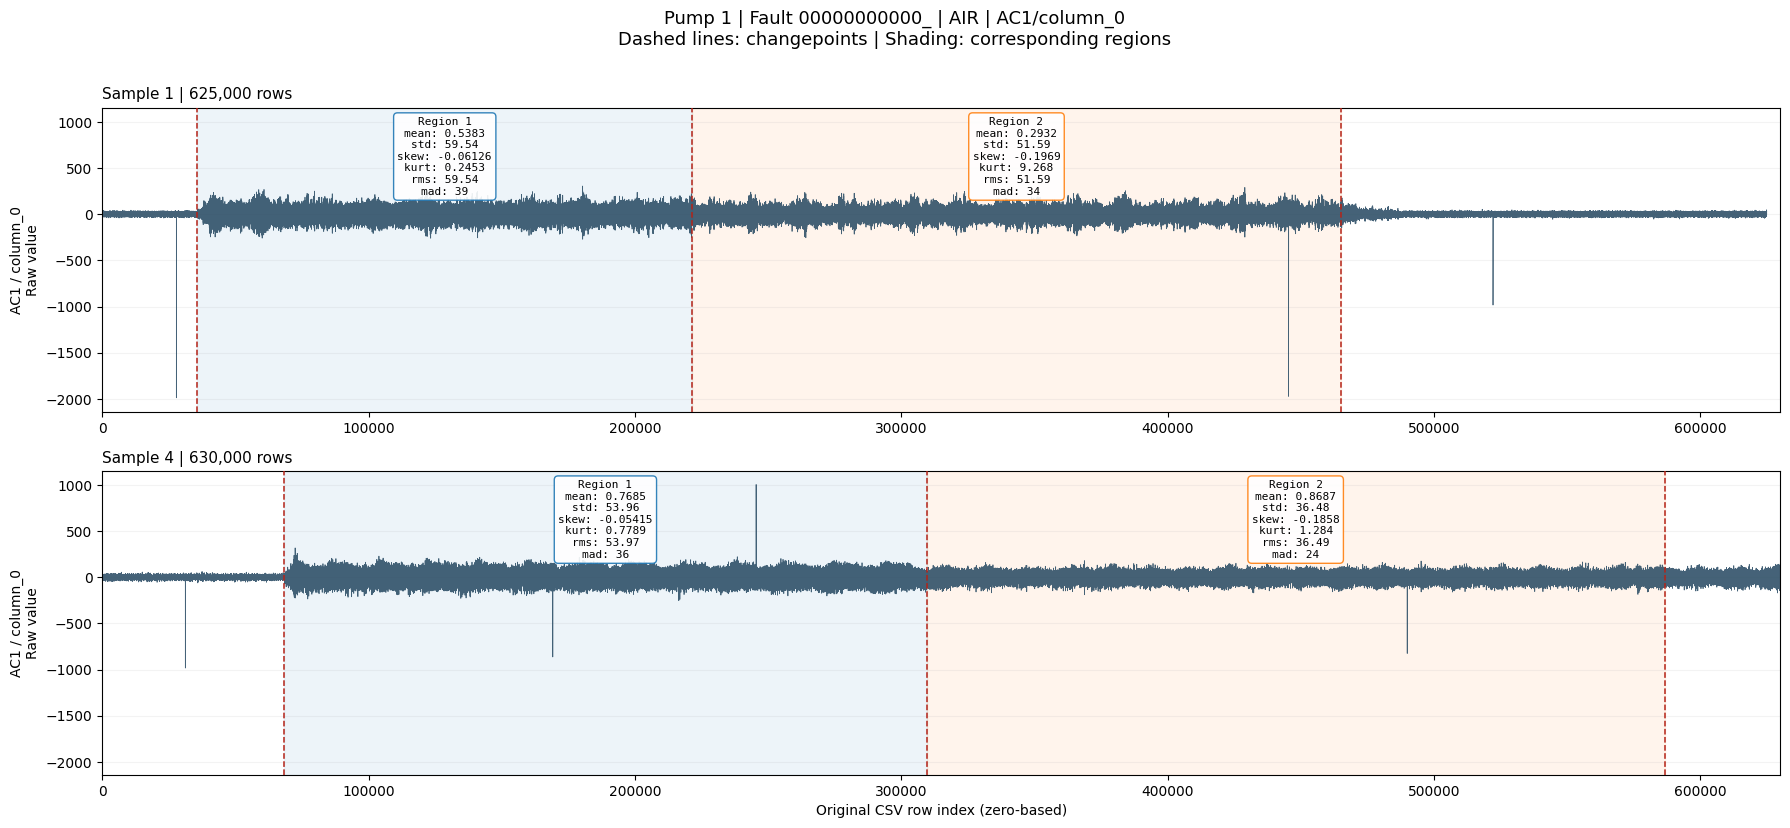

In [12]:
# Plot full recordings for one available signal/channel from the comparison.
selection = result['features'].iloc[0]
fig, axes, plot_result = plot_sample_regions(
    pump_no=selection['pump_id'],
    fault=selection['fault_id'],
    signal=selection['signal'],
    channel=selection['channel'],
    state=selection['state'],
)
plt.show()


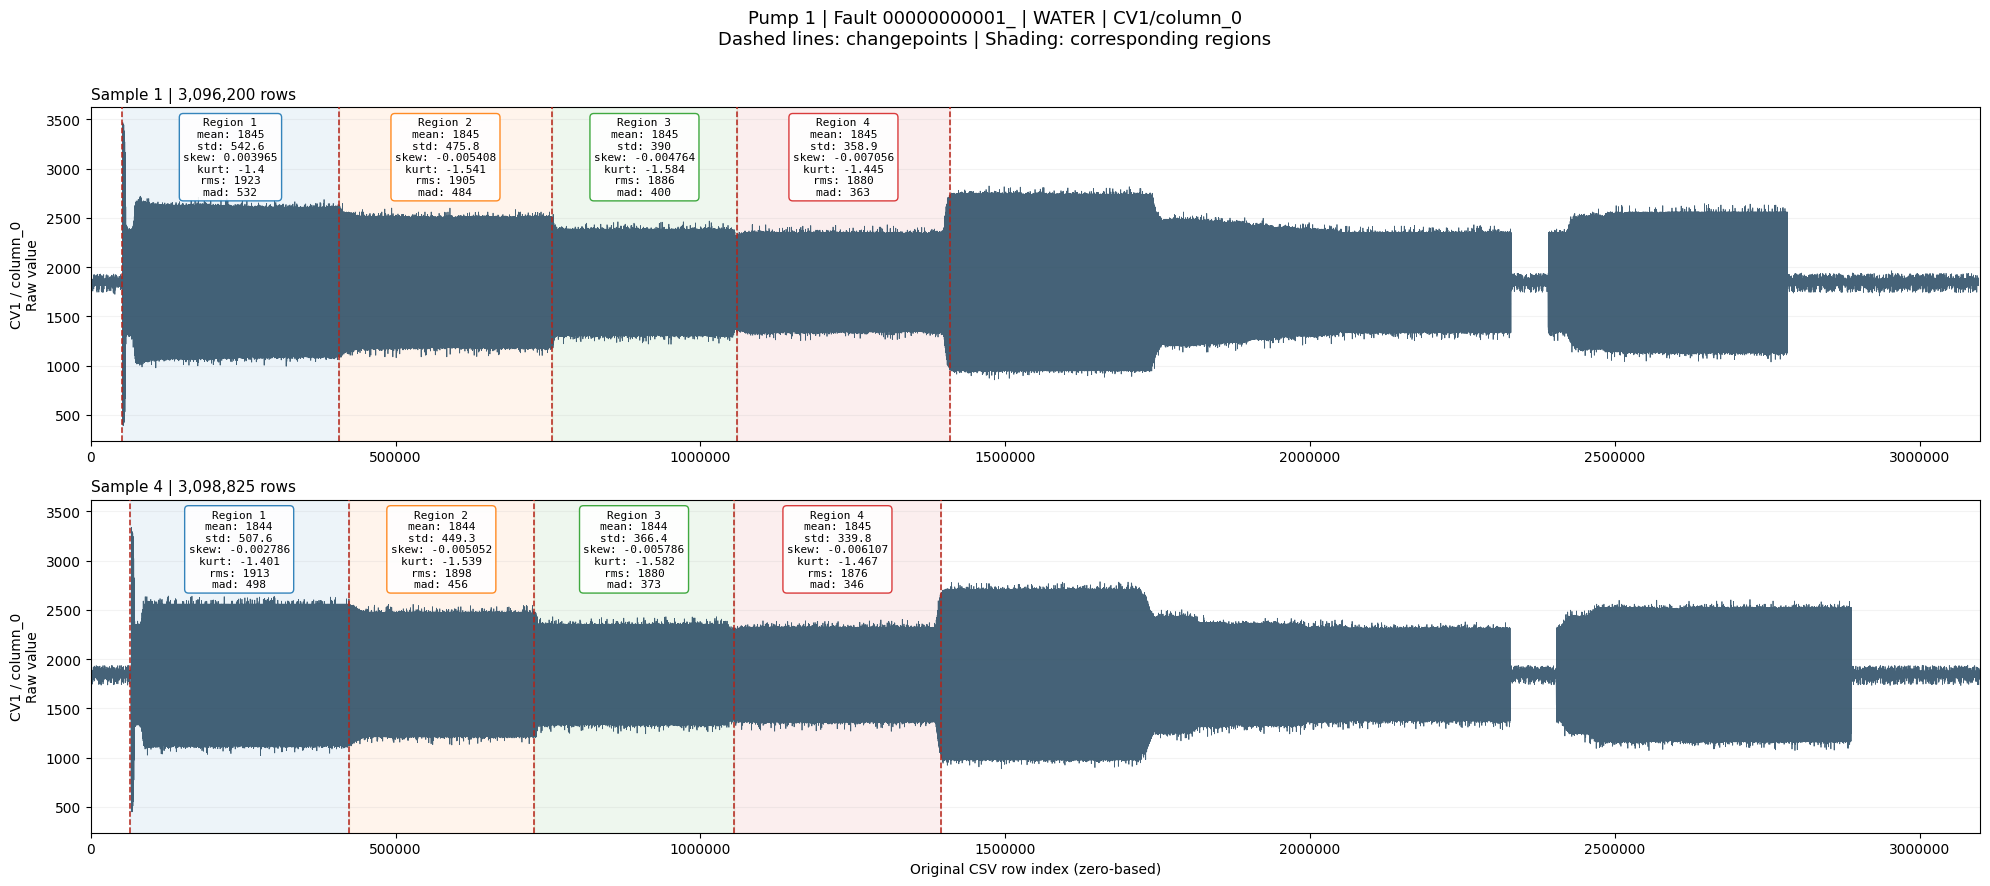

In [14]:
# Explicit example: choose the sensor/channel and samples you want.
fig, axes, plot_result = plot_sample_regions(
    pump_no=1,
    fault='00000000001_',
    signal='CV1',
    channel='column_0',
    state='water',
    sample_ids=[1, 4],  # Use actual sample IDs present in metadata.
    figsize=(20, 9),
    annotation_fontsize=8,
)
plt.show()
fig.savefig('pump_samples_with_regions.png', dpi=180, bbox_inches='tight')
